# Digital Signal Processing Assignment
## Part 1: Convolution (Input-Side Algorithm)

### Objective
- Generate noisy 50 Hz sine wave
- Apply 3-point moving average filter
- Implement manual convolution

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
FS=1000
t=np.linspace(0,1,FS)

f=50
clean_signal=np.sin(2*np.pi*f*t)

noise=0.5*np.random.normal(size=FS)
noisy_signal=clean_signal+noise

### Define Moving Average Filter

In [38]:
h=np.ones(3)/3

### Manual Convolution Function

In [39]:
def manual_convolution(x,h):
    Nx=len(x)
    Nh=len(h)
    y=np.zeros(Nx+Nh-1)

    for i in range(Nx):
        for j in range(Nh):
            y[i+j]+=x[i]*h[j]
    return y

In [40]:
filtered_signal= manual_convolution(noisy_signal,h)

### Result: Comparison Plot

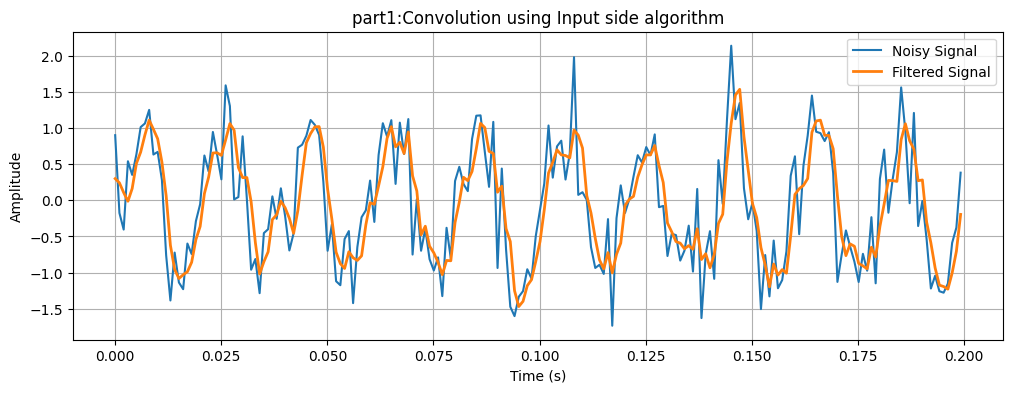

In [41]:
plt.figure(figsize=(12,4))
plt.plot(t[:200],noisy_signal[:200],label='Noisy Signal')
plt.plot(t[:200],filtered_signal[:200],label='Filtered Signal',linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title("part1:Convolution using Input side algorithm")
plt.grid(True)
plt.legend()
plt.show()

# Part 2: Manual Discrete Fourier Transform (DFT)
This section implements DFT manually using cosine and sine basis functions.

## Objective
- Generate a signal containing 60 Hz and 120 Hz components.
- Implement DFT manually (without using numpy.fft).
- Compute Real and Imaginary parts.
- Calculate the magnitude spectrum.
- Identify frequency peaks.

In [42]:
FS=1000
N=1000
t=np.linspace(0,1,N)

## Signal Generation
60 Hz + 120 Hz sine wave
Sampling Frequency = 1000 Hz
Duration = 1 second

In [43]:
signal_dft=np.sin(2*np.pi*60*t)+0.5*np.sin(2*np.pi*120*t)

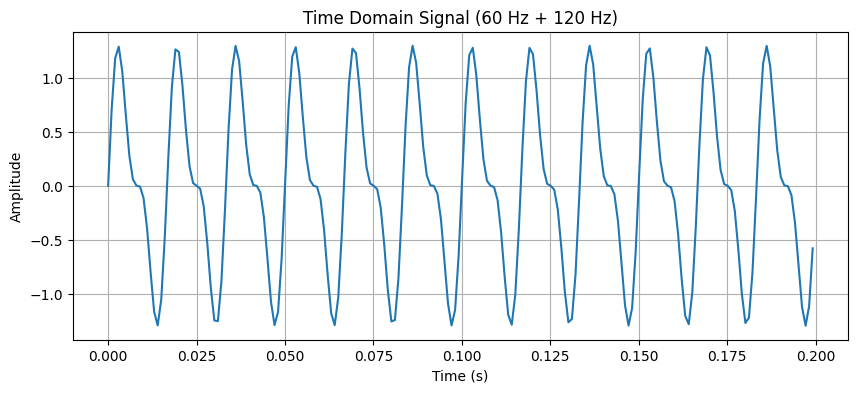

In [44]:
plt.figure(figsize=(10,4))
plt.plot(t[:200],signal_dft[:200])
plt.title("Time Domain Signal (60 Hz + 120 Hz)")
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Manual DFT Implementation
DFT is calculated using cosine and sine basis functions.
Real and Imaginary parts are computed using nested loops.

In [45]:
def calculate_dft(x):
    N=len(x)
    ReX=np.zeros(N)
    ImX=np.zeros(N)

    for k in range(N):
        for i in range(N):
            angle=2*np.pi*k*i/N
            ReX[k]+=x[i]*np.cos(angle)
            ImX[k]-=x[i]*np.sin(angle)
    
    MagX=np.sqrt(ReX**2+ImX**2)
    return MagX

In [46]:
mag=calculate_dft(signal_dft)

In [47]:
freq=np.arange(N)*(FS/N)

## Magnitude Spectrum
The magnitude is calculated as:

MagX[k] = sqrt(ReX^2 + ImX^2)

Peaks should appear at:
- 60 Hz
- 120 Hz

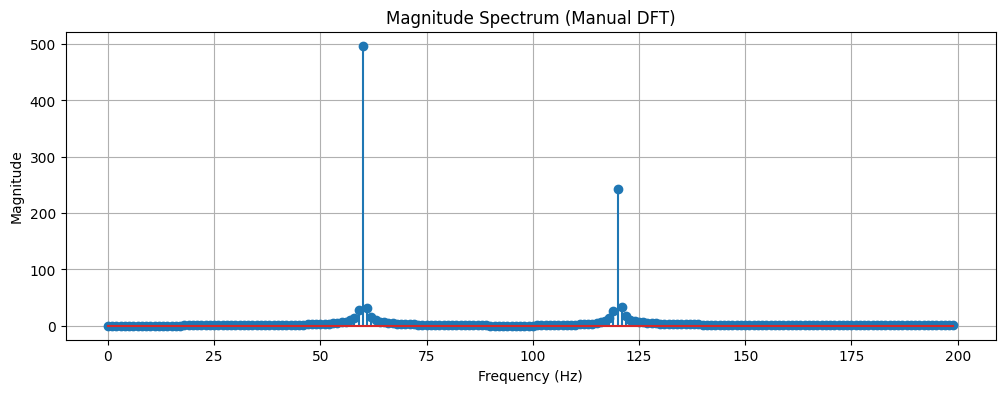

In [48]:
plt.figure(figsize=(12,4))
plt.stem(freq[:200],mag[:200])
plt.title("Magnitude Spectrum (Manual DFT)")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()